# U23AI009 ABSS ASSIGNMENT 2
Dataset: AgeDB

# Notebook Guide: Cross-Age Face Recognition on AgeDB

## What this notebook is doing

This notebook studies **face recognition under age variation** using the **AgeDB** dataset. The central idea is to learn an embedding function that maps a face image to a compact feature vector in which:

- images of the **same person** should be close together, even when their ages differ;
- images of **different people** should be separated;
- the learned embeddings can then be used for **identification** and **verification** without retraining on the test identities.

The notebook compares four approaches:

1. **FaceNet** — metric learning with a triplet-style objective.
2. **PFE (Probabilistic Face Embeddings)** — represents each face as a distribution, modeling uncertainty as well as the embedding mean.
3. **SphereFace** — classification with an angular margin intended to produce more discriminative face embeddings.
4. **AdaFace** — classification with an **adaptive angular margin** whose strength depends on embedding quality.

All four implementations use a **pretrained ResNet backbone** followed by a learned embedding head. The main difference is how each model is trained to make the embedding space discriminative.

## How to read the notebook

The workflow is:

**Dataset → preprocessing → balanced batches → backbone/embedding model → model-specific loss → training → embedding extraction → cross-age evaluation → plots and comparison**

A useful mental model is to separate the notebook into two stages:

> **Training:** learn a general-purpose face embedding space from the training identities.

> **Testing:** freeze that learned representation and ask whether it can recognize or verify identities that were not used to train the classifier.

The evaluation is therefore about the **quality of the embedding space**, not simply training-set classification accuracy.


## Codes and Stuff

## 1. Imports and Core Libraries

The imports reflect four main parts of the experiment:

- **PyTorch / torchvision:** neural-network construction, pretrained ResNet backbones, data loading, optimization, and tensor operations.
- **Pandas / pathlib / PIL:** dataset manifest handling and image loading.
- **scikit-learn:** ROC curves and ROC-AUC for verification.
- **Matplotlib / tqdm:** visualization and training progress.

The notebook is implemented around PyTorch `Dataset` / `DataLoader` abstractions so that the same data pipeline can be reused by all four models.


In [3]:
#imports
from torch.utils.data import DataLoader, Sampler, Dataset
import random
import math
from pathlib import Path
import pandas as pd
from torchvision import transforms, models
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## 2. Dataset Protocol and Identity Labels

The dataset manifest provides, for each image, the **person identity**, **age**, **age group** (`younger` or `older`), filename, and split.

A key design choice is the treatment of labels:

- **Training and validation** share one identity-label space because the classifier-based models need the same class indexing during validation.
- **Test identities are held out** from training. Their labels do not need to align with the training classifier because the final evaluation operates on **embeddings + person names**, not on the classifier's class IDs.

This distinction is important: the test stage evaluates whether the embedding generalizes to **unseen identities**.

For cross-age recognition, the interesting pairs are not arbitrary image pairs. They are specifically:

> **same person + different age group** versus **different person + different age group**.

That lets us measure how well identity survives substantial age variation.


In [4]:
#dataset function handles the management of the dataset.
def dataset(path, split=None):
    path = Path(path)
    manifest = pd.read_csv(path / "split_manifest.csv")

    if split == "test":
        # Test identities are held out / unseen during training. They
        # never go through the classifier (evaluate.py works purely off
        # embeddings + person_name), so they get their own label space —
        # it does not need to align with num_classes at all.
        split_manifest = manifest[manifest["split"] == "test"].copy()
        people = sorted(split_manifest["person_name"].unique())
        person_to_label = {p: i for i, p in enumerate(people)}

        return {
            "root": path,
            "manifest": split_manifest,
            "person_to_label": person_to_label,
        }

    # Train and validation MUST share one label space, since
    # train_sphere.py / train_adaface.py run both through the same
    # classifier head during validation loss computation.
    trainval_manifest = manifest[manifest["split"].isin(["train", "validation"])]
    people = sorted(trainval_manifest["person_name"].unique())
    person_to_label = {p: i for i, p in enumerate(people)}

    if split is not None:
        manifest = manifest[manifest["split"] == split].copy()
    else:
        manifest = trainval_manifest.copy()

    return {
        "root": path,
        "manifest": manifest,
        "person_to_label": person_to_label,
    }


In [5]:
#converting our dataset into torch dataset class
class FaceDataset(Dataset):

    def __init__(self, root, manifest, person_to_label, transform=None):
        self.root = Path(root)
        self.manifest = manifest.reset_index(drop=True)
        self.transform = transform

        people = sorted(self.manifest["person_name"].unique())

        self.person_to_label = person_to_label

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        row = self.manifest.iloc[index]

        image_path = (
            self.root
            / row["split"]
            / row["group"]
            / row["filename"]
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = self.person_to_label[row["person_name"]]

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "person_name": row["person_name"],
            "age": torch.tensor(int(row["age"]), dtype=torch.long),
            "group": row["group"],
        }

## 3. Data Augmentation and Preprocessing

Training images are resized to **224 × 224** and normalized using the standard ImageNet mean and standard deviation.

The training pipeline can additionally apply:

- random horizontal flipping;
- random rotation up to the configured angle;
- color jitter in brightness, contrast, and saturation;
- optional Gaussian noise;
- optional salt-and-pepper noise.

The noise mechanisms are configurable but are currently **disabled** in the run configurations.

Only training images receive the stochastic augmentations. Validation/test data use the deterministic part of the preprocessing pipeline.

### Why augmentation matters

A face-recognition embedding should represent **identity**, not incidental image conditions. Augmentation exposes the network to controlled changes so that it learns features that are more invariant to pose, lighting, small geometric changes, and other nuisance variation.


In [6]:
# for gaussian noise
class GaussianNoise:

    def __init__(self, std):
        self.std = std

    def __call__(self, tensor):

        noise = torch.randn_like(tensor) * self.std

        tensor = tensor + noise

        tensor = torch.clamp(
            tensor,
            0.0,
            1.0
        )

        return tensor


In [7]:
# for salt and pepper noise
class SaltPepperNoise:

    def __init__(self, probability):
        self.probability = probability

    def __call__(self, tensor):

        random_map = torch.rand_like(tensor)

        salt = (
            random_map
            < self.probability / 2
        )

        pepper = (
            (random_map >= self.probability / 2)
            & (random_map < self.probability)
        )

        tensor = tensor.clone()

        tensor[salt] = 1.0
        tensor[pepper] = 0.0

        return tensor


## 4. Why Use Person-Balanced Batches?

The custom `PersonBalancedBatchSampler` deliberately constructs batches around **identities**, rather than sampling images independently.

The current run configuration uses:

- **16 persons per batch**
- **4 images per person**
- 2 younger + 2 older images per person

so the effective batch size is:

$$
16 \times 4 = 64 \text{ images}.
$$

This structure is especially important for **metric-learning losses** such as triplet loss and PFE loss, because those objectives need meaningful positive and negative relationships *inside the same batch*.

For each selected identity, the sampler tries to include both age groups. That gives the model direct exposure to the central problem of the assignment: **preserving identity despite age changes**.


In [8]:
# for balanced sampling in batches
class PersonBalancedBatchSampler(Sampler):

    def __init__(
        self,
        dataset,
        persons_per_batch,
        images_per_person
    ):

        self.dataset = dataset
        self.persons_per_batch = persons_per_batch
        self.images_per_person = images_per_person

        if images_per_person < 2:
            raise ValueError(
                "images_per_person must be at least 2."
            )

        if persons_per_batch < 1:
            raise ValueError(
                "persons_per_batch must be at least 1."
            )

        if images_per_person % 2 != 0:
            raise ValueError(
                "images_per_person must be even so that "
                "younger and older images can be balanced."
            )

        # --------------------------------------------------
        # Index images by person and age group
        # --------------------------------------------------

        self.person_to_indices = {}

        for index, row in dataset.manifest.iterrows():

            person = row["person_name"]
            group = row["group"]

            if person not in self.person_to_indices:
                self.person_to_indices[person] = {
                    "younger": [],
                    "older": []
                }

            self.person_to_indices[
                person
            ][group].append(index)

        # --------------------------------------------------
        # Keep only identities with both age groups
        # --------------------------------------------------

        self.people = [
            person
            for person, groups in self.person_to_indices.items()
            if groups["younger"]
            and groups["older"]
        ]

        if len(self.people) < self.persons_per_batch:
            raise ValueError(
                "Not enough identities containing both "
                "younger and older images."
            )

        # --------------------------------------------------
        # Batch structure
        # --------------------------------------------------

        self.younger_per_person = (
            images_per_person // 2
        )

        self.older_per_person = (
            images_per_person // 2
        )

        self.batch_size = (
            persons_per_batch
            * images_per_person
        )

        # Match approximately one normal dataset epoch.
        self.num_batches = (
            len(dataset)
            // self.batch_size
        )

    def __iter__(self):

        # --------------------------------------------------
        # Generate the requested number of batches.
        #
        # Identities may appear in multiple batches during
        # an epoch, but never twice within the same batch.
        # --------------------------------------------------

        for _ in range(self.num_batches):

            selected_people = random.sample(
                self.people,
                self.persons_per_batch
            )

            batch = []

            for person in selected_people:

                younger = self.person_to_indices[
                    person
                ]["younger"]

                older = self.person_to_indices[
                    person
                ]["older"]

                # ------------------------------------------
                # Younger images
                # ------------------------------------------

                if len(younger) >= self.younger_per_person:

                    young_indices = random.sample(
                        younger,
                        self.younger_per_person
                    )

                else:

                    young_indices = random.choices(
                        younger,
                        k=self.younger_per_person
                    )

                # ------------------------------------------
                # Older images
                # ------------------------------------------

                if len(older) >= self.older_per_person:

                    old_indices = random.sample(
                        older,
                        self.older_per_person
                    )

                else:

                    old_indices = random.choices(
                        older,
                        k=self.older_per_person
                    )

                batch.extend(
                    young_indices
                )

                batch.extend(
                    old_indices
                )

            yield batch

    def __len__(self):
        return self.num_batches

In [9]:
# builds loader

def build_loader(data, config):

    root = data["root"]
    manifest = data["manifest"]
    person_to_label = data["person_to_label"]

    split = manifest["split"].iloc[0]
    training = split == "train"

    steps = []

    if config["preprocess"]["resize"]:
        steps.append(transforms.Resize((config["preprocess"]["image_size"],
                                        config["preprocess"]["image_size"])))

    if training and config["preprocess"]["horizontal_flip"]:
        steps.append(transforms.RandomHorizontalFlip())

    if training and config["preprocess"]["rotation_degrees"] > 0:
        steps.append(transforms.RandomRotation(config["preprocess"]["rotation_degrees"]))

    if training and config["preprocess"]["color_jitter"]:
        steps.append(transforms.ColorJitter(
            brightness=config["preprocess"]["brightness"],
            contrast=config["preprocess"]["contrast"],
            saturation=config["preprocess"]["saturation"],
        ))

    steps.append(transforms.ToTensor())

    if training and config["preprocess"]["gaussian_noise"]:
        steps.append(transforms.RandomApply(
            [GaussianNoise(config["preprocess"]["gaussian_std"])],
            p=config["preprocess"]["probability"]))

    if training and config["preprocess"]["salt_pepper_noise"]:
        steps.append(transforms.RandomApply(
            [SaltPepperNoise(config["preprocess"]["salt_pepper_probability"])],
            p=config["preprocess"]["probability"]))

    steps.append(transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                      std=[0.229, 0.224, 0.225]))

    transform = transforms.Compose(steps)

    ds = FaceDataset(root=root, manifest=manifest,
                     transform=transform, person_to_label=person_to_label)

    # balanced batches for training, and for validation only if requested
    # (needed for triplet/PFE losses; not needed for classifier-based models)
    use_balanced = config["person_balanced"] and (
        training or (split == "validation" and config.get("balance_validation", False))
    )

    if use_balanced:
        batch_sampler = PersonBalancedBatchSampler(
            dataset=ds,
            persons_per_batch=config["persons_per_batch"],
            images_per_person=config["images_per_person"],
        )
        loader = DataLoader(ds, batch_sampler=batch_sampler,
                            num_workers=config["num_workers"],
                            pin_memory=config["pin_memory"])
    else:
        loader = DataLoader(ds, batch_size=config["batch_size"],
                            shuffle=training,
                            num_workers=config["num_workers"],
                            pin_memory=config["pin_memory"],
                            drop_last=training)

    return loader

In [10]:
# returns loader

def get_loader(loader_configs):
    path = r"C:\Abyss\Assignment-2\dataset"
    train_data = dataset(path,"train")
    val_data = dataset(path,"validation")
    train_loader = build_loader(train_data, loader_configs)
    validation_loader = build_loader(val_data, loader_configs)
    return train_loader, validation_loader

## 5. Shared Network Structure: ResNet Backbone → Face Embedding

All four models start from the same general representation-learning template:

$$
\text{Face Image}
\rightarrow
\text{ResNet-50 Backbone}
\rightarrow
\text{Embedding Head}
\rightarrow
\text{Face Representation}.
$$

The ResNet classifier (`backbone.fc`) is removed and replaced by a learned embedding head.

In the current experiment configurations, the backbone is **pretrained ResNet-50** and the embedding dimension is **128**.

The important conceptual distinction is:

- the **backbone** learns visual features from the image;
- the **embedding head** converts those features into the representation used for face recognition;
- the **loss function** determines what properties that representation should have.

Thus, two models can use the same ResNet but learn very different embedding spaces because their training objectives are different.


In [11]:
# FaceNet model

class FaceNet(nn.Module):

    def __init__(self, backbone, input_features, embedding_dim):
        super().__init__()

        self.backbone = backbone

        self.embedding = nn.Linear(
            input_features,
            embedding_dim
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)

        return x

In [12]:
# builds facenet

def build_facenet(config):

    backbone_name = config.get("backbone", "resnet50")
    embedding_dim = config.get("embedding_dim", 128)
    pretrained = config.get("pretrained", True)

    if backbone_name == "resnet18":
        backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet34":
        backbone = models.resnet34(
            weights=models.ResNet34_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet50":
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet101":
        backbone = models.resnet101(
            weights=models.ResNet101_Weights.DEFAULT
            if pretrained else None
        )

    else:
        raise ValueError(
            f"Unsupported FaceNet backbone: {backbone_name}"
        )

    input_features = backbone.fc.in_features

    backbone.fc = nn.Identity()

    model = FaceNet(
        backbone=backbone,
        input_features=input_features,
        embedding_dim=embedding_dim
    )

    return model

## 6. Model 1 — FaceNet

### Architecture

The FaceNet implementation is:

$$
x \rightarrow \text{ResNet-50} \rightarrow \text{Linear}(2048 \rightarrow 128) \rightarrow \ell_2\text{-normalization}.
$$

The final normalization means the embedding lies on the unit hypersphere:

$$
\|f(x)\|_2 = 1.
$$

Because of this, the dot product between two embeddings is equivalent to their **cosine similarity**.

### Loss: Batch-All Triplet Loss

FaceNet is trained with a triplet-style metric-learning objective. For an anchor embedding $a$, a positive embedding $p$ from the same identity, and a negative embedding $n$ from a different identity:

$$
L_{triplet}
=
\max\left(
0,\,
s(a,n)-s(a,p)+m
\right),
$$

where $s(\cdot,\cdot)$ is cosine similarity and $m=0.2$ in the training function.

The implementation is specifically **batch-all**, meaning it does not choose only one hardest positive/negative example. It forms losses over **all valid positive-vs-negative combinations in the batch** and averages them.

The objective therefore encourages:

$$
s(a,p) \ge s(a,n) + m.
$$

### What to watch during training

The training loop reports the genuine and impostor similarities. A healthy embedding space should show a growing gap:

$$
\text{mean genuine similarity}
-
\text{mean impostor similarity}
> 0.
$$

This is a useful diagnostic because low triplet loss alone does not tell us the whole story.


In [13]:
# PFE

class PFE(nn.Module):

    def __init__(
        self,
        backbone,
        input_features,
        embedding_dim
    ):
        super().__init__()

        self.backbone = backbone

        self.mean = nn.Linear(
            input_features,
            embedding_dim
        )

        self.log_variance = nn.Linear(
            input_features,
            embedding_dim
        )

    def forward(self, x):

        features = self.backbone(x)

        mean = self.mean(features)
        log_variance = self.log_variance(features)

        return mean, log_variance

In [14]:
# builds PFE

def build_pfe(config):

    backbone_name = config.get(
        "backbone",
        "resnet50"
    )

    embedding_dim = config.get(
        "embedding_dim",
        128
    )

    pretrained = config.get(
        "pretrained",
        True
    )

    if backbone_name == "resnet18":

        backbone = models.resnet18(
            weights=
            models.ResNet18_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet34":

        backbone = models.resnet34(
            weights=
            models.ResNet34_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet50":

        backbone = models.resnet50(
            weights=
            models.ResNet50_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet101":

        backbone = models.resnet101(
            weights=
            models.ResNet101_Weights.DEFAULT
            if pretrained else None
        )

    else:

        raise ValueError(
            f"Unsupported PFE backbone: "
            f"{backbone_name}"
        )

    input_features = backbone.fc.in_features

    backbone.fc = nn.Identity()

    model = PFE(
        backbone=backbone,
        input_features=input_features,
        embedding_dim=embedding_dim
    )

    return model

## 7. Model 2 — PFE (Probabilistic Face Embeddings)

### Core idea

Unlike FaceNet, PFE does not represent a face with a single deterministic vector. It predicts two vectors:

- a **mean** $\mu$;
- a **log-variance** parameter used to derive per-dimension uncertainty.

The variance is computed as:

$$
\sigma^2 = \operatorname{softplus}(\text{log\_variance}) + \text{variance\_floor}.
$$

This lets the representation encode not only *where* the face lies in embedding space, but also *how certain* the model is about that representation.

### Loss used in this notebook

For two faces, the implementation forms:

$$
V = \sigma_i^2 + \sigma_j^2,
$$

and a variance-weighted squared distance:

$$
D_{ij}
=
\frac{(\mu_i-\mu_j)^2}{V}.
$$

The pairwise quantity used by the loss is approximately:

$$
L_{pair}
=
\frac{1}{2}
\left(
D_{ij}+\log V
\right),
$$

averaged over embedding dimensions.

The full objective has three parts:

$$
L
=
L_{positive}
+
L_{negative}
+
\lambda L_{variance},
$$

where:

- **positive loss:** minimizes the pair loss for same-identity pairs;
- **negative loss:** uses a hinge term $\max(0, m-L_{pair})$ to push different identities apart;
- **variance regularization:** penalizes extreme variance values through $(\log \sigma^2)^2$.

The notebook uses a negative margin of **2.0** and variance regularization weight **0.01**.

### Why PFE is different

FaceNet assumes a point embedding. PFE instead treats the embedding as **uncertain**. This is particularly relevant to face recognition because image quality, pose, occlusion, and age variation can make some face representations inherently less reliable.


In [15]:
# sphereface classifier

class SphereFaceClassifier(nn.Module):

    def __init__(self, embedding_dim, num_classes, margin=2, scale=30.0):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        self.margin = margin
        self.scale = scale

    def forward(self, embedding, labels=None):
        embedding = F.normalize(embedding, p=2, dim=1)
        weight = F.normalize(self.weight, p=2, dim=1)
        cosine = embedding @ weight.T

        if labels is None:
            return cosine * self.scale

        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))

        k = torch.floor(self.margin * theta / math.pi)
        sign = 1.0 - 2.0 * (k % 2)
        psi = sign * torch.cos(self.margin * theta) - 2.0 * k

        idx = torch.arange(embedding.size(0), device=embedding.device)
        output = cosine.clone()
        output[idx, labels] = psi[idx, labels]

        return output * self.scale

In [16]:
class SphereFace(nn.Module):

    def __init__(self, backbone, embedding, classifier):
        super().__init__()

        self.backbone = backbone
        self.embedding = embedding
        self.classifier = classifier

    def forward(self, x):
        features = self.backbone(x)
        embedding = self.embedding(features)

        return embedding

    def classify(self, embedding, labels=None):
        return self.classifier(embedding, labels)


In [17]:
# builds sphereface

def build_sphereface(config):

    backbone_name = config.get("backbone", "resnet50")
    embedding_dim = config.get("embedding_dim", 512)
    pretrained = config.get("pretrained", True)
    num_classes = config["num_classes"]
    margin = config.get("margin", 4)

    if backbone_name == "resnet18":
        backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )

    elif backbone_name == "resnet34":
        backbone = models.resnet34(
            weights=models.ResNet34_Weights.DEFAULT if pretrained else None
        )

    elif backbone_name == "resnet50":
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT if pretrained else None
        )

    elif backbone_name == "resnet101":
        backbone = models.resnet101(
            weights=models.ResNet101_Weights.DEFAULT if pretrained else None
        )

    else:
        raise ValueError(
            f"Unsupported SphereFace backbone: {backbone_name}"
        )

    input_features = backbone.fc.in_features
    backbone.fc = nn.Identity()

    embedding = nn.Linear(
        input_features,
        embedding_dim
    )

    classifier = SphereFaceClassifier(
        embedding_dim=embedding_dim,
        num_classes=num_classes,
        margin=margin
    )

    return SphereFace(
        backbone=backbone,
        embedding=embedding,
        classifier=classifier
    )


## 8. Model 3 — SphereFace

### Core idea

SphereFace is a **classification-based face recognition** approach. Instead of directly constructing positive/negative pairs, the network learns one class weight vector for each training identity and makes the correct identity angularly closer to the embedding.

The classifier normalizes both embeddings and class weights, so classification is based primarily on **angles / cosine similarity**.

The key idea of SphereFace is an **angular margin**. For the target class, the angle $\theta$ is transformed using a multiplicative margin:

$$
\psi(\theta)=\cos(m\theta)
$$

(with the implementation using the piecewise formulation needed for the SphereFace / A-Softmax construction).

The target logit is replaced by this margin-adjusted value and then multiplied by a scale factor.

### Loss

The classifier outputs logits and the training function applies:

$$
L = \operatorname{CrossEntropyLoss}(\text{logits}, y).
$$

So the overall recipe is:

$$
\text{embedding}
\rightarrow
\text{angular-margin classifier}
\rightarrow
\text{softmax cross-entropy}.
$$

The angular margin makes the class decision boundaries more demanding, encouraging identities to occupy more discriminative regions of the embedding space.

### Implementation note for interpreting the results

In the current notebook, the **training call uses `model.classify(embeddings)` without labels**, which invokes the classifier's no-label branch and therefore uses the **scaled cosine logits without the angular margin**. The validation loss, however, calls `model.classify(embeddings, labels)` and therefore applies the margin.

This means the *code as written* is not training with the full margin formulation that the SphereFace classifier implements. Keep this distinction in mind when interpreting the SphereFace results.


In [18]:
# adaface classifier

class AdaFaceClassifier(nn.Module):
    def __init__(self, embedding_dim, num_classes, margin=0.4, h=0.333, scale=64.0, t_alpha=0.01):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        self.margin = margin
        self.h = h
        self.scale = scale
        self.t_alpha = t_alpha
        # init to match initial embedding norm ~2-5, not 20/100
        self.register_buffer("batch_mean", torch.tensor(5.0))
        self.register_buffer("batch_std", torch.tensor(5.0))

    def forward(self, embedding, labels):
        cosine = F.linear(F.normalize(embedding, p=2, dim=1),
                          F.normalize(self.weight, p=2, dim=1))
        norms = torch.norm(embedding, p=2, dim=1, keepdim=True)

        if self.training:
            with torch.no_grad():
                mean = norms.mean()
                std = norms.std().clamp_min(1e-6)
                self.batch_mean = self.t_alpha * mean + (1-self.t_alpha) * self.batch_mean
                self.batch_std = self.t_alpha * std + (1-self.t_alpha) * self.batch_std

        # DETACH to prevent norm-collapse incentive
        quality = (norms.detach() - self.batch_mean) / self.batch_std.clamp_min(1e-6)
        quality = quality.clamp(-1.0, 1.0)
        adaptive_margin = self.margin * (1.0 + self.h * quality)
        adaptive_margin = adaptive_margin.squeeze(1)

        # stable cos(theta+m) without acos
        idx = torch.arange(embedding.size(0), device=embedding.device)
        target_cos = cosine[idx, labels]
        sin_theta = torch.sqrt((1.0 - target_cos.pow(2)).clamp(min=1e-6))
        cos_m = torch.cos(adaptive_margin)
        sin_m = torch.sin(adaptive_margin)
        target_cos_m = target_cos * cos_m - sin_theta * sin_m

        logits = cosine.clone()
        logits[idx, labels] = target_cos_m
        return logits * self.scale

    def forward_no_margin(self, embedding):
        cosine = F.linear(F.normalize(embedding, p=2, dim=1),
                          F.normalize(self.weight, p=2, dim=1))
        return cosine * self.scale

In [19]:
# adaface

class AdaFace(nn.Module):

    def __init__(self, backbone, embedding, classifier):
        super().__init__()

        self.backbone = backbone
        self.embedding = embedding
        self.classifier = classifier

    def forward(self, x):
        features = self.backbone(x)
        embedding = self.embedding(features)

        return embedding

    def classify(self, embedding, labels):
        return self.classifier(embedding, labels)

## 9. Model 4 — AdaFace

### Core idea

AdaFace also uses classification, but its angular margin is **adaptive to the quality of the embedding**.

The embedding norm is used as a proxy for image/feature quality. The implementation maintains an exponential moving average of the batch mean and standard deviation of embedding norms, then computes a normalized quality value:

$$
q =
\operatorname{clip}
\left(
\frac{\|f(x)\|_2-\mu_{EMA}}{\sigma_{EMA}},
-1,1
\right).
$$

The angular margin is then adjusted as:

$$
m_{adaptive}
=
m(1+hq).
$$

Therefore, the margin is not identical for every image.

### Target logit

The target-class cosine similarity is converted using the adaptive angular margin:

$$
\cos(\theta + m_{adaptive}).
$$

The implementation computes this in a numerically stable way using sine/cosine identities rather than explicitly applying `acos` for the margin operation.

### Loss

After the adaptive-margin logits are produced, the notebook uses ordinary cross-entropy:

$$
L =
\operatorname{CrossEntropyLoss}
(\text{adaptive-margin logits}, y).
$$

So AdaFace is best thought of as:

> **quality-adaptive angular-margin classification + cross-entropy**

rather than a separate metric-learning loss such as triplet loss.

### Important distinction from FaceNet

FaceNet directly optimizes relative distances/similarities between examples.

AdaFace instead optimizes class separation during training and relies on the resulting embedding geometry for verification/identification at test time.


In [20]:
# builds adaface

def build_adaface(config):

    backbone_name = config.get("backbone", "resnet50")
    embedding_dim = config.get("embedding_dim", 512)
    pretrained = config.get("pretrained", True)
    num_classes = config["num_classes"]

    if backbone_name == "resnet18":
        backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet34":
        backbone = models.resnet34(
            weights=models.ResNet34_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet50":
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
            if pretrained else None
        )

    elif backbone_name == "resnet101":
        backbone = models.resnet101(
            weights=models.ResNet101_Weights.DEFAULT
            if pretrained else None
        )

    else:
        raise ValueError(
            f"Unsupported AdaFace backbone: {backbone_name}"
        )

    input_features = backbone.fc.in_features
    backbone.fc = nn.Identity()

    embedding = nn.Linear(
        input_features,
        embedding_dim
    )

    classifier = AdaFaceClassifier(
        embedding_dim=embedding_dim,
        num_classes=num_classes,
        margin=config.get("margin", 0.4),
        h=config.get("h", 0.333),
        scale=config.get("scale", 64.0),
        t_alpha=config.get("t_alpha", 0.01)
    )

    return AdaFace(
        backbone=backbone,
        embedding=embedding,
        classifier=classifier
    )

In [21]:
# builds our model

def build_model(config):

    if config["name"] == "facenet":
        return build_facenet(config)

    if config["name"] == "pfe":
        return build_pfe(config)

    if config["name"] == "sphereface":
        return build_sphereface(config)

    if config["name"] == "adaface":
        return build_adaface(config)

    raise ValueError(f"Unknown model name: {config['name']}")

In [22]:
# gets model type

def get_model_type(model):
    model_type = model.__class__.__name__

    if model_type == "FaceNet":
        return "FaceNet"

    elif model_type == "PFE":
        return "PFE"

    elif model_type == "SphereFace":
        return "SphereFace"

    elif model_type == "AdaFace":
        return "AdaFace"

    else:
        raise ValueError(
            f"Unknown model type: {model_type}"
        )


## 10. Model-Agnostic Training vs Model-Specific Objectives

At this point the notebook has four different learning objectives:

| Model | Representation | Main training objective |
|---|---|---|
| **FaceNet** | deterministic 128-D normalized vector | Batch-all triplet loss |
| **PFE** | mean + variance / uncertainty | probabilistic pair loss + negative hinge + variance regularization |
| **SphereFace** | deterministic embedding + angular classifier | Cross-entropy over SphereFace-style angular-margin logits *(see implementation note above)* |
| **AdaFace** | deterministic embedding + quality-adaptive classifier | Cross-entropy over adaptive angular-margin logits |

The shared training ingredients—optimizer, gradient clipping, epochs, train/validation passes—are separated from the **model-specific loss logic**.

This is a useful design pattern: the architecture of the training pipeline stays reusable while the objective defines what “good embeddings” means for each model.


In [23]:
# batch all triplet loss for facenet

def batch_all_triplet_loss(embeddings, labels, margin):
    """
    Average the hinge loss over every valid (anchor, positive,
    negative) triplet in the batch, instead of only the single
    hardest positive/negative per anchor. This gives dense gradient
    signal and is far less prone to collapsing to a degenerate
    solution than strict batch-hard mining.
    """

    similarity = embeddings @ embeddings.T

    same = labels[:, None] == labels[None, :]
    different = ~same
    same.fill_diagonal_(False)

    positive_sim = similarity[same]      # all genuine pair similarities
    negative_sim = similarity[different]  # all impostor pair similarities

    if positive_sim.numel() == 0 or negative_sim.numel() == 0:
        return None, None, None

    # All-pairs triplet loss: every positive vs every negative.
    # [P, 1] - [1, N] -> [P, N]
    losses = F.relu(
        negative_sim[None, :]
        - positive_sim[:, None]
        + margin
    )

    loss = losses.mean()

    return loss, positive_sim.mean(), negative_sim.mean()

In [24]:
# train facenet

def train_facenet(model, loader):

    train_loader, validation_loader = loader

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    # Embedding head gets a much higher LR — with batch-all loss it now
    # receives gradient from every valid triplet, not just one per anchor,
    # so it needs room to actually move.
    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.backbone.parameters(),
                "lr": 1e-5,
            },
            {
                "params": model.embedding.parameters(),
                "lr": 1e-3,
            },
        ],
        weight_decay=1e-4,
    )

    epochs = 20
    margin = 0.2

    for epoch in range(epochs):

        # ==================================================
        # Training
        # ==================================================

        model.train()

        train_loss = 0.0
        train_batches = 0
        train_genuine_sim = 0.0
        train_impostor_sim = 0.0

        for batch in tqdm(
    train_loader,
    desc=f"Epoch {epoch+1}/{epochs} - Training",
    leave=False):

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            labels = batch["label"].to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            embeddings = model(images)

            loss, genuine_sim, impostor_sim = batch_all_triplet_loss(
                embeddings, labels, margin
            )

            if loss is None:
                continue

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            train_loss += loss.item()
            train_genuine_sim += genuine_sim.item()
            train_impostor_sim += impostor_sim.item()
            train_batches += 1

        train_loss /= max(train_batches, 1)
        train_genuine_sim /= max(train_batches, 1)
        train_impostor_sim /= max(train_batches, 1)

        # ==================================================
        # Validation
        # ==================================================

        model.eval()

        validation_loss = 0.0
        validation_batches = 0
        val_genuine_sim = 0.0
        val_impostor_sim = 0.0

        with torch.inference_mode():

            for batch in validation_loader:

                images = batch["image"].to(
                    device,
                    non_blocking=True
                )

                labels = batch["label"].to(
                    device,
                    non_blocking=True
                )

                embeddings = model(images)

                loss, genuine_sim, impostor_sim = batch_all_triplet_loss(
                    embeddings, labels, margin
                )

                if loss is None:
                    continue

                validation_loss += loss.item()
                val_genuine_sim += genuine_sim.item()
                val_impostor_sim += impostor_sim.item()
                validation_batches += 1

        validation_loss /= max(
            validation_batches,
            1
        )
        val_genuine_sim /= max(validation_batches, 1)
        val_impostor_sim /= max(validation_batches, 1)

        # Canary: if this gap isn't growing over the first few epochs,
        # the model is heading toward collapse again.
        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f} | "
            f"Train sim gap (gen-imp): {train_genuine_sim - train_impostor_sim:+.4f} | "
            f"Val sim gap (gen-imp): {val_genuine_sim - val_impostor_sim:+.4f}"
        )

    return model

In [25]:
# pfe loss

def pfe_loss(
    means,
    log_variances,
    labels,
    variance_floor=0.05,
    variance_regularization=0.01,
    negative_margin=2.0
):

    variances = F.softplus(log_variances) + variance_floor

    pair_variance = variances.unsqueeze(1) + variances.unsqueeze(0)
    mean_difference = means.unsqueeze(1) - means.unsqueeze(0)

    squared_difference = mean_difference.pow(2) / pair_variance

    pair_loss = 0.5 * (squared_difference + torch.log(pair_variance))
    pair_loss = pair_loss.mean(dim=2)

    eye = torch.eye(len(labels), dtype=torch.bool, device=labels.device)
    same = (labels[:, None] == labels[None, :]) & ~eye
    different = (labels[:, None] != labels[None, :])   # diagonal excluded

    if not same.any() or not different.any():
        return None

    positive_loss = pair_loss[same].mean()
    negative_loss = F.relu(negative_margin - pair_loss[different]).mean()
    variance_regularization_loss = torch.log(variances).pow(2).mean()

    return (
        positive_loss
        + negative_loss
        + variance_regularization * variance_regularization_loss
    )

In [26]:
# trains a pfe model

def train_pfe(model, loader):

    train_loader, validation_loader = loader

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    epochs = 20

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        train_loss = 0.0
        train_batches = 0

        for batch in train_loader:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            labels = batch["label"].to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            means, log_variances = model(images)

            loss = pfe_loss(
                means,
                log_variances,
                labels
            )

            if loss is None:
                continue

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            train_loss += loss.item()
            train_batches += 1

        train_loss /= max(train_batches, 1)

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        validation_loss = 0.0
        validation_batches = 0

        with torch.inference_mode():

            for batch in validation_loader:

                images = batch["image"].to(
                    device,
                    non_blocking=True
                )

                labels = batch["label"].to(
                    device,
                    non_blocking=True
                )

                means, log_variances = model(images)

                loss = pfe_loss(
                    means,
                    log_variances,
                    labels
                )

                if loss is None:
                    continue

                validation_loss += loss.item()
                validation_batches += 1

        validation_loss /= max(
            validation_batches,
            1
        )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f}"
        )

    return model

In [27]:
# trains a sphereface model

def train_sphere(model, loader):

    train_loader, validation_loader = loader

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    loss_function = nn.CrossEntropyLoss()

    epochs = 20

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        train_loss = 0.0
        train_batches = 0

        for batch in train_loader:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            labels = batch["label"].to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            embeddings = model(images)

            logits = model.classify(embeddings)   # no margin, scaled cosine

            loss = loss_function(
                logits,
                labels
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            train_loss += loss.item()
            train_batches += 1

        train_loss /= max(train_batches, 1)

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        validation_loss = 0.0
        validation_batches = 0

        with torch.no_grad():

            for batch in validation_loader:

                images = batch["image"].to(
                    device,
                    non_blocking=True
                )

                labels = batch["label"].to(
                    device,
                    non_blocking=True
                )

                embeddings = model(images)

                logits = model.classify(
                    embeddings,
                    labels
                )

                loss = loss_function(
                    logits,
                    labels
                )

                validation_loss += loss.item()
                validation_batches += 1

        validation_loss /= max(
            validation_batches,
            1
        )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f}"
        )

    return model

In [28]:
# trains an adaface model

def train_adaface(model, loader):
    train_loader, validation_loader = loader

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW([
      {"params": model.backbone.parameters(), "lr": 1e-5},
      {"params": model.embedding.parameters(), "lr": 1e-3},
      {"params": model.classifier.parameters(), "lr": 1e-3},
    ], weight_decay=1e-4)

    epochs = 20

    for epoch in range(epochs):
        # -------------------------
        # Training
        # -------------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_samples = 0
        train_batches = 0

        for batch in train_loader:
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            optimizer.zero_grad()
            embeddings = model(images)
            logits = model.classify(embeddings, labels) # with margin for loss
            loss = loss_function(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_loss += loss.item()

            # acc WITHOUT margin for monitoring
            with torch.no_grad():
                logits_nomargin = model.classifier.forward_no_margin(embeddings)
                predictions = logits_nomargin.argmax(dim=1)
                train_correct += (predictions == labels).sum().item()

            train_samples += labels.size(0)
            train_batches += 1

        train_loss /= max(train_batches, 1)
        train_accuracy = train_correct / max(train_samples, 1)

        # -------------------------
        # Validation - also no margin
        # -------------------------
        # -------------------------
        # Validation - also no margin
        # -------------------------
        model.eval()
        validation_loss = 0.0
        validation_correct = 0
        validation_samples = 0
        validation_batches = 0  # <- add this

        with torch.no_grad():
            for batch in validation_loader:
                images = batch["image"].to(device, non_blocking=True)
                labels = batch["label"].to(device, non_blocking=True)

                embeddings = model(images)
                logits = model.classifier.forward_no_margin(embeddings)
                loss = loss_function(logits, labels)

                validation_loss += loss.item()
                predictions = logits.argmax(dim=1)
                validation_correct += (predictions == labels).sum().item()
                validation_samples += labels.size(0)
                validation_batches += 1  # <- add this

        validation_loss /= max(validation_batches, 1)
        validation_accuracy = validation_correct / max(validation_samples, 1)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {validation_loss:.4f} | Val Acc: {validation_accuracy:.4f}"
        )

    return model


In [29]:
# trains a model

def train(model,loader):
    model_type = get_model_type(model)
    if model_type == "FaceNet":
        return train_facenet(model,loader)
    if model_type == "PFE":
        return train_pfe(model,loader)
    if model_type == "SphereFace":
        return train_sphere(model,loader)
    if model_type == "AdaFace":
        return train_adaface(model,loader)

## 11. From Images to Test Embeddings

After training, the classifier itself is no longer the main object of interest. The notebook runs the test images through the network and extracts the learned representation.

For PFE, the output is `(mean, log_variance)`, and the evaluation stage uses the **mean embedding** as the representation.

For the other models, the network directly returns the embedding.

The resulting table-like structure stores:

- embedding vector;
- person identity;
- age;
- younger/older group;
- training-space label when available.

The test identities are unseen during training, so evaluation asks whether the representation itself generalizes.


In [30]:
# generate embeddings for testing

def generate_embeddings(model, loader):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)
    model.eval()

    embeddings = []
    labels = []
    person_names = []
    ages = []
    groups = []

    with torch.no_grad():

        for batch in loader:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            output = model(images)

            # PFE returns (mean, log_variance).
            # Other models return the embedding directly.
            if isinstance(output, tuple):
                output = output[0]

            output = output.float().cpu()

            embeddings.append(output)

            labels.extend(
                batch["label"].cpu().numpy()
            )

            person_names.extend(
                batch["person_name"]
            )

            ages.extend(
                batch["age"].cpu().numpy()
            )

            groups.extend(
                batch["group"]
            )

    embeddings = torch.cat(
        embeddings,
        dim=0
    ).numpy()

    labels = np.asarray(labels)
    ages = np.asarray(ages)

    return {
        "embeddings": embeddings,
        "labels": labels,
        "person_names": person_names,
        "ages": ages,
        "groups": groups,
    }


## 12. Cross-Age Identification

**Identification** asks:

> Given a query face, which identity in the gallery is the most similar?

The notebook evaluates both directions:

- **younger → older:** use older images as the gallery and younger images as queries;
- **older → younger:** reverse the direction.

For each gallery identity, multiple images are averaged into a single **prototype** and then normalized.

Similarity is cosine similarity:

$$
s(q,g)=\frac{q\cdot g}{\|q\|\|g\|}.
$$

The gallery identities are ranked by similarity, and performance is reported using:

- **Rank-1:** the correct identity is the top match;
- **Rank-5:** the correct identity appears in the top 5;
- **Rank-10:** the correct identity appears in the top 10.

Higher is better for all three.

Because the test identities are unseen, these metrics directly measure **cross-age identity retrieval** rather than memorization of the training classes.


In [31]:
# evaluate identification

def evaluate_identification(embeddings):

    vectors = embeddings["embeddings"]
    people = np.asarray(embeddings["person_names"])
    groups = np.asarray(embeddings["groups"])

    # Normalize once so dot product = cosine similarity.
    vectors = vectors / np.linalg.norm(
        vectors,
        axis=1,
        keepdims=True
    ).clip(min=1e-8)

    results = {}

    for gallery_group, query_group in [
        ("younger", "older"),
        ("older", "younger")
    ]:

        gallery_mask = groups == gallery_group
        query_mask = groups == query_group

        gallery_vectors = vectors[gallery_mask]
        gallery_people = people[gallery_mask]

        query_vectors = vectors[query_mask]
        query_people = people[query_mask]

        # --------------------------------------------------
        # Build one normalized prototype per gallery identity.
        # --------------------------------------------------

        gallery_identities, identity_indices = np.unique(
            gallery_people,
            return_inverse=True
        )

        n_identities = len(gallery_identities)
        embedding_dim = gallery_vectors.shape[1]

        prototypes = np.zeros(
            (n_identities, embedding_dim),
            dtype=gallery_vectors.dtype
        )

        np.add.at(
            prototypes,
            identity_indices,
            gallery_vectors
        )

        counts = np.bincount(
            identity_indices,
            minlength=n_identities
        ).astype(gallery_vectors.dtype)

        prototypes /= counts[:, None]

        prototypes /= np.linalg.norm(
            prototypes,
            axis=1,
            keepdims=True
        ).clip(min=1e-8)

        # --------------------------------------------------
        # Query × identity cosine similarity.
        # --------------------------------------------------

        similarity = (
            query_vectors @ prototypes.T
        )

        # --------------------------------------------------
        # Rank identities by similarity.
        # --------------------------------------------------

        rankings = np.argsort(
            -similarity,
            axis=1
        )

        ranked_identities = gallery_identities[
            rankings
        ]

        # --------------------------------------------------
        # Rank-1 / Rank-5 / Rank-10.
        # --------------------------------------------------

        correct = (
            ranked_identities
            == query_people[:, None]
        )

        rank1 = correct[:, :1].any(axis=1).mean()

        rank5 = correct[
            :, :min(5, n_identities)
        ].any(axis=1).mean()

        rank10 = correct[
            :, :min(10, n_identities)
        ].any(axis=1).mean()

        n_queries = len(query_people)

        results[
            f"{gallery_group}_to_{query_group}"
        ] = {
            "queries": n_queries,
            "gallery_identities": n_identities,
            "rank1": float(rank1),
            "rank5": float(rank5),
            "rank10": float(rank10),
        }

    return results

## 13. Cross-Age Verification

**Verification** is a binary decision:

> Are these two face images the same person?

The notebook creates two score populations:

- **genuine pairs:** same person, different age group;
- **impostor pairs:** different people, across the two age groups.

Cosine similarity is the verification score. A threshold $t$ accepts a pair when:

$$
s \ge t.
$$

### Metrics

**ROC-AUC**

Measures how well genuine pairs are ranked above impostor pairs over all thresholds. Higher is better.

**FAR (False Accept Rate)**

Fraction of impostor pairs incorrectly accepted.

**TAR (True Accept Rate)**

Fraction of genuine pairs correctly accepted.

**EER (Equal Error Rate)**

The operating point where false accept and false reject rates are approximately equal. Lower is better.

**TAR @ FAR**

The notebook also reports TAR at very strict false-accept constraints:

- FAR = **1%**
- FAR = **0.1%**

These are especially informative for face recognition because a system can look good on average while still performing poorly when false matches must be extremely rare.

### Balanced impostor sampling

There can be vastly more impostor pairs than genuine pairs. The code therefore samples the impostor population so that the ROC/AUC calculation uses a balanced verification set.

This avoids letting the huge number of possible impostor combinations dominate simple aggregate statistics.


In [32]:
# evaluate verification

def evaluate_verification(embeddings, seed=42):

    vectors = embeddings["embeddings"]
    people = np.asarray(embeddings["person_names"])
    groups = np.asarray(embeddings["groups"])

    # --------------------------------------------------
    # Normalize embeddings
    # --------------------------------------------------

    vectors = vectors / np.linalg.norm(
        vectors,
        axis=1,
        keepdims=True
    ).clip(min=1e-8)

    younger_mask = groups == "younger"
    older_mask = groups == "older"

    younger_vectors = vectors[younger_mask]
    older_vectors = vectors[older_mask]

    younger_people = people[younger_mask]
    older_people = people[older_mask]

    # --------------------------------------------------
    # All young × old cosine similarities
    # --------------------------------------------------

    similarity_matrix = (
        younger_vectors @ older_vectors.T
    )

    # --------------------------------------------------
    # Genuine / impostor masks
    # --------------------------------------------------

    genuine_mask = (
        younger_people[:, None]
        == older_people[None, :]
    )

    genuine_scores = similarity_matrix[
        genuine_mask
    ].astype(np.float32)

    all_impostor_scores = similarity_matrix[
        ~genuine_mask
    ].astype(np.float32)

    if len(genuine_scores) == 0:
        raise ValueError(
            "No genuine cross-age pairs found."
        )

    if len(all_impostor_scores) == 0:
        raise ValueError(
            "No impostor cross-age pairs found."
        )

    # --------------------------------------------------
    # Sample impostors to balance the verification set
    #
    # This prevents the enormous number of impostor
    # pairs from dominating ordinary accuracy.
    # --------------------------------------------------

    rng = np.random.default_rng(seed)

    n_impostors = min(
        len(genuine_scores),
        len(all_impostor_scores)
    )

    impostor_indices = rng.choice(
        len(all_impostor_scores),
        size=n_impostors,
        replace=False
    )

    impostor_scores = all_impostor_scores[
        impostor_indices
    ]

    # --------------------------------------------------
    # Balanced verification set
    # --------------------------------------------------

    scores = np.concatenate([
        genuine_scores,
        impostor_scores
    ])

    labels = np.concatenate([
        np.ones(
            len(genuine_scores),
            dtype=np.int8
        ),
        np.zeros(
            len(impostor_scores),
            dtype=np.int8
        )
    ])

    # --------------------------------------------------
    # ROC / AUC
    # --------------------------------------------------

    auc = roc_auc_score(
        labels,
        scores
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores
    )

    fnr = 1.0 - tpr

    # --------------------------------------------------
    # Equal Error Rate
    # --------------------------------------------------

    eer_index = np.nanargmin(
        np.abs(fnr - fpr)
    )

    eer = float(
        (
            fpr[eer_index]
            + fnr[eer_index]
        ) / 2.0
    )

    eer_threshold = float(
        thresholds[eer_index]
    )

    # --------------------------------------------------
    # Balanced accuracy at EER threshold
    # --------------------------------------------------

    predictions = scores >= eer_threshold

    genuine_predictions = predictions[
        :len(genuine_scores)
    ]

    impostor_predictions = predictions[
        len(genuine_scores):
    ]

    true_positive_rate = genuine_predictions.mean()

    true_negative_rate = (
        ~impostor_predictions
    ).mean()

    balanced_accuracy = (
        true_positive_rate
        + true_negative_rate
    ) / 2.0

    # --------------------------------------------------
    # TAR at fixed FAR
    # --------------------------------------------------

    def tar_at_far(target_far):

        valid = fpr <= target_far

        if not np.any(valid):
            return 0.0, np.nan

        index = np.where(valid)[0][-1]

        return (
            float(tpr[index]),
            float(thresholds[index])
        )

    tar_1, threshold_1 = tar_at_far(
        0.01
    )

    tar_01, threshold_01 = tar_at_far(
        0.001
    )

    # --------------------------------------------------
    # Return results
    # --------------------------------------------------

    return {
        "auc": float(auc),

        "eer": eer,
        "eer_threshold": eer_threshold,

        "balanced_accuracy": float(
            balanced_accuracy
        ),

        "tar_at_far_1": tar_1,
        "tar_at_far_1_threshold": threshold_1,

        "tar_at_far_01": tar_01,
        "tar_at_far_01_threshold": threshold_01,

        "genuine_scores": genuine_scores,
        "impostor_scores": impostor_scores,

        "fpr": fpr,
        "tpr": tpr,

        "num_genuine_pairs": len(
            genuine_scores
        ),

        "num_impostor_pairs": len(
            impostor_scores
        ),

        "num_impostor_pairs_available": len(
            all_impostor_scores
        ),
    }

## 14. Age-Gap Analysis

Verification performance alone does not tell us *how* age affects recognition.

The age-gap analysis isolates genuine cross-age pairs and computes their cosine similarity as a function of the absolute age difference:

$$
\Delta age = |age_{older}-age_{younger}|.
$$

The notebook bins genuine pairs into:

- **0–9 years**
- **10–19 years**
- **20–29 years**
- **30–39 years**
- **40+ years**

For each bin it reports count, mean, median, standard deviation, minimum, and maximum similarity.

A common interpretation is:

> If mean genuine similarity systematically decreases as the age gap grows, the embedding is becoming less identity-stable under larger age changes.

This analysis should be interpreted together with identification and verification metrics rather than in isolation.


In [33]:
# evaluate age gap

def evaluate_age_gap(embeddings):

    vectors = embeddings["embeddings"]
    people = np.asarray(embeddings["person_names"])
    groups = np.asarray(embeddings["groups"])
    ages = np.asarray(embeddings["ages"])

    # Normalize so dot product = cosine similarity.
    vectors = vectors / np.linalg.norm(
        vectors,
        axis=1,
        keepdims=True
    ).clip(min=1e-8)

    younger_mask = groups == "younger"
    older_mask = groups == "older"

    younger_vectors = vectors[younger_mask]
    older_vectors = vectors[older_mask]

    younger_people = people[younger_mask]
    older_people = people[older_mask]

    younger_ages = ages[younger_mask]
    older_ages = ages[older_mask]

    # --------------------------------------------------
    # All young × old cosine similarities
    # --------------------------------------------------

    similarity_matrix = (
        younger_vectors @ older_vectors.T
    )

    # --------------------------------------------------
    # Genuine cross-age pairs
    # --------------------------------------------------

    genuine_mask = (
        younger_people[:, None]
        == older_people[None, :]
    )

    if not genuine_mask.any():
        raise ValueError(
            "No genuine cross-age pairs found."
        )

    # Get coordinates of genuine pairs.
    y_idx, o_idx = np.where(
        genuine_mask
    )

    pairs = pd.DataFrame({
        "person_name": younger_people[y_idx],
        "younger_age": younger_ages[y_idx].astype(int),
        "older_age": older_ages[o_idx].astype(int),
        "age_gap": np.abs(
            older_ages[o_idx] - younger_ages[y_idx]
        ).astype(int),
        "similarity": similarity_matrix[
            y_idx,
            o_idx
        ].astype(np.float32),
    })

    # --------------------------------------------------
    # Age-gap bins
    # --------------------------------------------------

    bins = [
        0,
        10,
        20,
        30,
        40,
        np.inf
    ]

    labels = [
        "0-9",
        "10-19",
        "20-29",
        "30-39",
        "40+"
    ]

    pairs["age_gap_bin"] = pd.cut(
        pairs["age_gap"],
        bins=bins,
        labels=labels,
        right=False
    )

    # --------------------------------------------------
    # Summary statistics
    # --------------------------------------------------

    summary = (
        pairs
        .groupby(
            "age_gap_bin",
            observed=True
        )["similarity"]
        .agg([
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ])
        .reset_index()
    )

    return {
        "pairs": pairs,
        "summary": summary,
    }


In [34]:
# evaluate similarity

def evaluate_similarity(embeddings):

    vectors = embeddings["embeddings"]
    people = np.asarray(embeddings["person_names"])
    groups = np.asarray(embeddings["groups"])

    # Normalize so dot product = cosine similarity.
    vectors = vectors / np.linalg.norm(
        vectors,
        axis=1,
        keepdims=True
    ).clip(min=1e-8)

    younger_mask = groups == "younger"
    older_mask = groups == "older"

    younger_vectors = vectors[younger_mask]
    older_vectors = vectors[older_mask]

    younger_people = people[younger_mask]
    older_people = people[older_mask]

    # Compute every young × old similarity in one operation.
    similarity_matrix = (
        younger_vectors @ older_vectors.T
    )

    # Same person = genuine pair.
    genuine_mask = (
        younger_people[:, None]
        == older_people[None, :]
    )

    genuine_scores = similarity_matrix[
        genuine_mask
    ].astype(np.float32)

    # Different person = impostor pair.
    impostor_scores = similarity_matrix[
        ~genuine_mask
    ].astype(np.float32)

    if len(genuine_scores) == 0:
        raise ValueError(
            "No genuine cross-age pairs found."
        )

    if len(impostor_scores) == 0:
        raise ValueError(
            "No impostor cross-age pairs found."
        )

    return {
        "genuine_scores": genuine_scores,
        "impostor_scores": impostor_scores,

        "genuine_mean": float(
            genuine_scores.mean()
        ),
        "genuine_median": float(
            np.median(genuine_scores)
        ),

        "impostor_mean": float(
            impostor_scores.mean()
        ),
        "impostor_median": float(
            np.median(impostor_scores)
        ),
    }


In [35]:
# evaluate a model

def evaluate(model,loader_config):

    test_data = dataset(r"C:\Abyss\Assignment-2\dataset","test")

    test_loader = build_loader(test_data,loader_config)

    embeddings = generate_embeddings(model,test_loader)

    identification = evaluate_identification(embeddings)

    verification = evaluate_verification(embeddings)

    age_gap = evaluate_age_gap(embeddings)

    similarity = evaluate_similarity(embeddings)

    return {
        "identification": identification,
        "verification": verification,
        "age_gap": age_gap,
        "similarity": similarity
    }

## 15. How to Read the Final Plots

The `analyze()` function summarizes four complementary views of embedding quality.

### ROC curve
A curve closer to the top-left indicates better separation between genuine and impostor verification scores. ROC-AUC summarizes this separation.

### Genuine vs impostor similarity distributions
A strong recognizer should produce **high genuine similarities** and **lower impostor similarities**, with relatively little overlap.

The vertical threshold shown is the EER operating threshold.

### Similarity vs age gap
This plot asks whether genuine similarity deteriorates as the age difference grows. Ideally, the decline is limited.

### Rank-1 / Rank-5 / Rank-10 identification
These metrics show how reliably the correct identity can be retrieved from the gallery.

When comparing models, avoid relying on a single metric. A model might have similar Rank-1 accuracy to another model but substantially better low-FAR verification performance, which can be more important for practical face-recognition systems.


In [36]:
# analyzes evaluation results and gives plots and stuff.


def analyze(results, model_name):

    identification = results["identification"]
    verification = results["verification"]
    age_gap = results["age_gap"]
    similarity = results["similarity"]

    # ==================================================
    # Text Results
    # ==================================================

    print("FACE RECOGNITION EVALUATION RESULTS")
    print("=" * 60)
    print()

    # ----------------------------------------------
    # Identification
    # ----------------------------------------------

    print("CROSS-AGE IDENTIFICATION")
    print("-" * 60)

    for direction, metrics in identification.items():

        print()
        print(direction.replace("_", " ").title())

        print(
            f"Queries: "
            f"{metrics['queries']}"
        )

        print(
            f"Gallery identities: "
            f"{metrics['gallery_identities']}"
        )

        print(
            f"Rank-1 accuracy: "
            f"{metrics['rank1']:.4f}"
        )

        print(
            f"Rank-5 accuracy: "
            f"{metrics['rank5']:.4f}"
        )

        print(
            f"Rank-10 accuracy: "
            f"{metrics['rank10']:.4f}"
        )

    # ----------------------------------------------
    # Verification
    # ----------------------------------------------

    print()
    print()
    print("CROSS-AGE VERIFICATION")
    print("-" * 60)

    print(
        f"Genuine pairs: "
        f"{verification['num_genuine_pairs']}"
    )

    print(
        f"Impostor pairs sampled: "
        f"{verification['num_impostor_pairs']}"
    )

    print(
        f"Impostor pairs available: "
        f"{verification['num_impostor_pairs_available']}"
    )

    print(
        f"ROC-AUC: "
        f"{verification['auc']:.4f}"
    )

    print(
        f"EER: "
        f"{verification['eer']:.4f}"
    )

    print(
        f"EER threshold: "
        f"{verification['eer_threshold']:.4f}"
    )

    print(
        f"Balanced accuracy @ EER: "
        f"{verification['balanced_accuracy']:.4f}"
    )

    print(
        f"TAR @ FAR=1%: "
        f"{verification['tar_at_far_1']:.4f}"
    )

    print(
        f"TAR @ FAR=1% threshold: "
        f"{verification['tar_at_far_1_threshold']:.4f}"
    )

    print(
        f"TAR @ FAR=0.1%: "
        f"{verification['tar_at_far_01']:.4f}"
    )

    print(
        f"TAR @ FAR=0.1% threshold: "
        f"{verification['tar_at_far_01_threshold']:.4f}"
    )

    # ----------------------------------------------
    # Similarity
    # ----------------------------------------------

    print()
    print()
    print("SIMILARITY")
    print("-" * 60)

    print(
        f"Genuine mean: "
        f"{similarity['genuine_mean']:.4f}"
    )

    print(
        f"Genuine median: "
        f"{similarity['genuine_median']:.4f}"
    )

    print(
        f"Impostor mean: "
        f"{similarity['impostor_mean']:.4f}"
    )

    print(
        f"Impostor median: "
        f"{similarity['impostor_median']:.4f}"
    )

    # ----------------------------------------------
    # Age Gap
    # ----------------------------------------------

    print()
    print()
    print("AGE GAP ANALYSIS")
    print("-" * 60)

    gap_summary = age_gap["summary"]

    display(gap_summary)

    # ==================================================
    # Plot 1: ROC Curve
    # ==================================================

    plt.figure(figsize=(7, 6))

    plt.plot(
        verification["fpr"],
        verification["tpr"],
        label=f"AUC = {verification['auc']:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Chance"
    )

    plt.scatter(
        verification["eer"],
        1 - verification["eer"],
        label=f"EER = {verification['eer']:.4f}"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(
        f"{model_name} - Cross-Age Verification ROC"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

    # ==================================================
    # Plot 2: Similarity Distributions
    # ==================================================

    plt.figure(figsize=(8, 6))

    plt.hist(
        similarity["genuine_scores"],
        bins=50,
        alpha=0.6,
        density=True,
        label="Genuine"
    )

    plt.hist(
        similarity["impostor_scores"],
        bins=50,
        alpha=0.6,
        density=True,
        label="Impostor"
    )

    plt.axvline(
        verification["eer_threshold"],
        linestyle="--",
        label=(
            f"EER threshold = "
            f"{verification['eer_threshold']:.3f}"
        )
    )

    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")
    plt.title(
        f"{model_name} - Genuine vs Impostor Similarity"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

    # ==================================================
    # Plot 3: Age Gap
    # ==================================================

    plt.figure(figsize=(8, 6))

    x = np.arange(
        len(gap_summary)
    )

    plt.bar(
        x,
        gap_summary["mean"],
        yerr=gap_summary["std"].fillna(0),
        capsize=4
    )

    plt.xticks(
        x,
        gap_summary["age_gap_bin"].astype(str)
    )

    plt.xlabel("Age Gap (years)")
    plt.ylabel(
        "Mean Genuine Cosine Similarity"
    )

    plt.title(
        f"{model_name} - Genuine Similarity vs Age Gap"
    )

    plt.grid(
        alpha=0.3,
        axis="y"
    )

    plt.tight_layout()

    plt.show()

    # ==================================================
    # Plot 4: Identification
    # ==================================================

    directions = list(
        identification.keys()
    )

    rank1 = [
        identification[d]["rank1"]
        for d in directions
    ]

    rank5 = [
        identification[d]["rank5"]
        for d in directions
    ]

    rank10 = [
        identification[d]["rank10"]
        for d in directions
    ]

    x = np.arange(
        len(directions)
    )

    width = 0.25

    plt.figure(figsize=(9, 6))

    plt.bar(
        x - width,
        rank1,
        width,
        label="Rank-1"
    )

    plt.bar(
        x,
        rank5,
        width,
        label="Rank-5"
    )

    plt.bar(
        x + width,
        rank10,
        width,
        label="Rank-10"
    )

    plt.xticks(
        x,
        [
            direction.replace(
                "_",
                " → "
            )
            for direction in directions
        ]
    )

    plt.ylim(
        0,
        1
    )

    plt.ylabel("Accuracy")
    plt.title(
        f"{model_name} - Cross-Age Identification"
    )
    plt.legend()

    plt.grid(
        alpha=0.3,
        axis="y"
    )

    plt.tight_layout()

    plt.show()

## 16. End-to-End Pipeline

The `pipeline()` function ties the notebook together:

$$
\boxed{
\text{read manifest}
\rightarrow
\text{build loaders}
\rightarrow
\text{build model}
\rightarrow
\text{train}
\rightarrow
\text{extract test embeddings}
\rightarrow
\text{evaluate}
\rightarrow
\text{visualize}
}
$$

For each experiment, the pipeline automatically determines the number of training/validation identities and supplies that number to the classifier-based models.

This makes the final four run sections comparable: the data protocol and evaluation pipeline are shared, while the **model configuration and loss function** are changed.


In [37]:
def pipeline(config):
    path = r"C:\Abyss\Assignment-2\dataset"

    print("1. Reading dataset manifest...", flush=True)
    trainval_info = dataset(path, None)

    num_classes = len(trainval_info["person_to_label"])
    config["model"]["num_classes"] = num_classes

    print(
        f"2. num_classes = {num_classes} | "
        f"max label = {max(trainval_info['person_to_label'].values())}",
        flush=True
    )

    print("3. Building loaders...", flush=True)
    loader = get_loader(config["loader"])
    print("4. Loaders built.", flush=True)

    print("5. Building model...", flush=True)
    model = build_model(config["model"])
    print("6. Model built.", flush=True)

    print("7. Starting training...", flush=True)
    trained = train(model, loader)

    print("8. Starting evaluation...", flush=True)
    results = evaluate(trained, config["loader"])

    print("9. Starting analysis...", flush=True)
    analyze(results, config["model"]["name"])

## 17. Experiment 1 — FaceNet

This run uses the common preprocessing and person-balanced batches with:

- pretrained **ResNet-50** backbone;
- **128-D normalized embedding**;
- triplet margin **0.2**;
- AdamW with a smaller learning rate for the backbone and a larger learning rate for the embedding head.

The main question is:

> How well does direct metric learning with batch-all triplet loss preserve identity across age?


## FaceNet Run

In [36]:
preprocess_config = {
    "resize": True,
    "image_size": 224,
    "horizontal_flip": True,
    "rotation_degrees": 10,
    "color_jitter": True,
    "brightness": 0.15,
    "contrast": 0.15,
    "saturation": 0.15,
    "gaussian_noise": False,
    "gaussian_std": 0.05,
    "probability": 0.5,
    "salt_pepper_noise": False,
    "salt_pepper_probability": 0.01
}

loader_config = {
    "preprocess": preprocess_config,
    "person_balanced": True,
    "persons_per_batch": 16,
    "images_per_person": 4,
    "num_workers": 0,
    "pin_memory": True,
    "batch_size": 64
}

model_config = {
    "name": "facenet",
    "backbone": "resnet50",
    "embedding_dim": 128,
    "pretrained": True,
    "num_classes": None,
    "margin": 0.2
}

facenet_config = {
    "loader": loader_config,
    "model": model_config
}

1. Reading dataset manifest...
2. num_classes = 480 | max label = 479
3. Building loaders...
4. Loaders built.
5. Building model...
6. Model built.
7. Starting training...


Epoch 01/20 | Train Loss: 0.1137 | Validation Loss: 0.0993 | Train sim gap (gen-imp): +0.1901 | Val sim gap (gen-imp): +0.2333


Epoch 02/20 | Train Loss: 0.0810 | Validation Loss: 0.0926 | Train sim gap (gen-imp): +0.2892 | Val sim gap (gen-imp): +0.2799


Epoch 03/20 | Train Loss: 0.0708 | Validation Loss: 0.0877 | Train sim gap (gen-imp): +0.3319 | Val sim gap (gen-imp): +0.2890


Epoch 04/20 | Train Loss: 0.0633 | Validation Loss: 0.0865 | Train sim gap (gen-imp): +0.3519 | Val sim gap (gen-imp): +0.3115


...

Epoch 17/20 | Train Loss: 0.0257 | Validation Loss: 0.0754 | Train sim gap (gen-imp): +0.5081 | Val sim gap (gen-imp): +0.3546


Epoch 18/20 | Train Loss: 0.0242 | Validation Loss: 0.0757 | Train sim gap (gen-imp): +0.5132 | Val sim gap (gen-imp): +0.3523


Epoch 19/20 | Train Loss: 0.0235 | Validation Loss: 0.0733 | Train sim gap (gen-imp): +0.5185 | Val sim gap (gen-imp): +0.3515


Epoch 20/20 | Train Loss: 0.0219 | Validation Loss: 0.0747 | Train sim gap (gen-imp): +0.5248 | Val sim gap (gen-imp): +0.3593
8. Starting evaluation...
9. Starting analysis...
FACE RECOGNITION EVALUATION RESULTS

CROSS-AGE IDENTIFICATION
------------------------------------------------------------

Younger To Older
Queries: 1120
Gallery identities: 86
Rank-1 accuracy: 0.2241
Rank-5 accuracy: 0.5563
Rank-10 accuracy: 0.7259

Older To Younger
Queries: 1118
Gallery identities: 86
Rank-1 accuracy: 0.2147
Rank-5 accuracy: 0.5107
Rank-10 accuracy: 0.6896


CROSS-AGE VERIFICATION
------------------------------------------------------------
Genuine pairs: 15770
Impostor pairs sampled: 15770
Impostor pairs available: 1236390
ROC-AUC: 0.8139
EER: 0.2652
EER threshold: 0.2662
Balanced accuracy @ EER: 0.7348
TAR @ FAR=1%: 0.0938
TAR @ FAR=1% threshold: 0.6772
TAR @ FAR=0.1%: 0.0188
TAR @ FAR=0.1% threshold: 0.7850


SIMILARITY
------------------------------------------------------------
Genuine m

,age_gap_bin,count,mean,median,std,min,max
0,0-9,586,0.441069,0.452733,0.210156,-0.258482,0.924117
1,10-19,3448,0.447462,0.458274,0.198532,-0.418065,0.955679
2,20-29,4543,0.416078,0.424972,0.203509,-0.334882,0.941546
3,30-39,3668,0.383127,0.393124,0.213731,-0.393757,0.906082
4,40+,3525,0.335281,0.348740,0.222699,-0.378256,0.883927


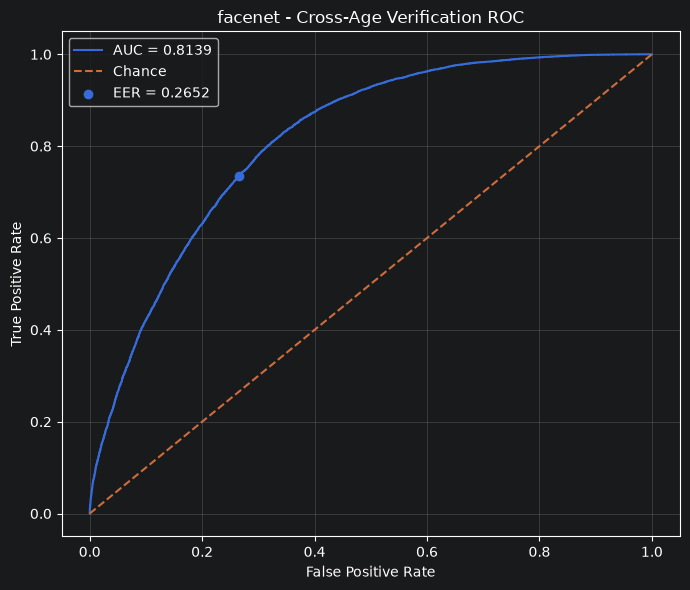

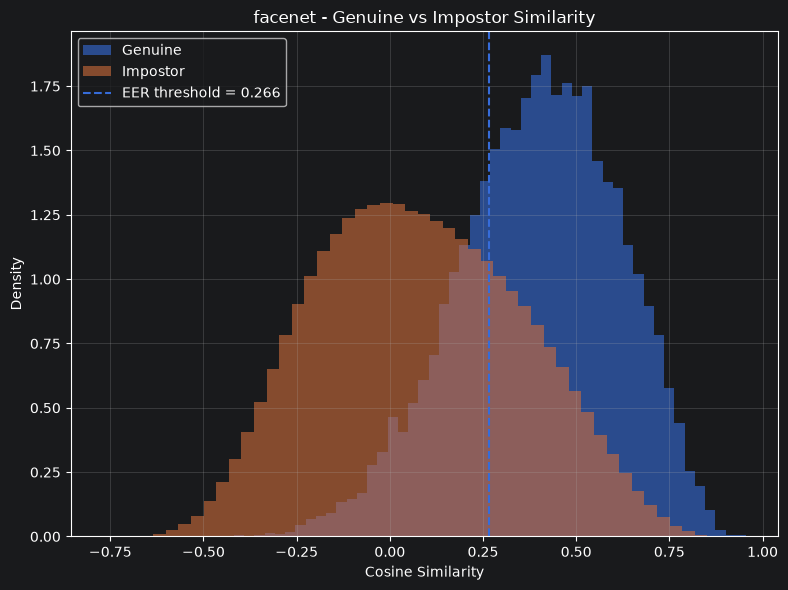

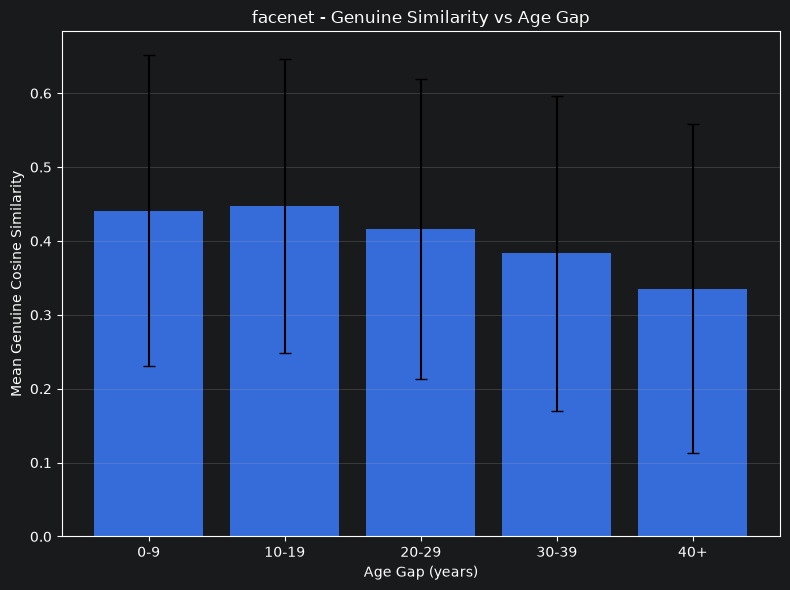

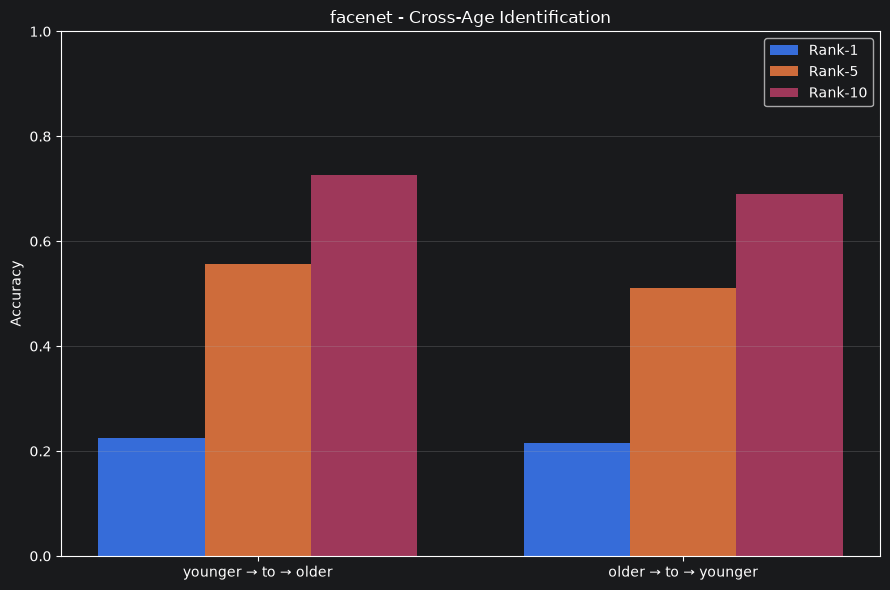

In [37]:
pipeline(facenet_config)

## 18. Experiment 2 — PFE

This run uses the same data pipeline but changes the representation to a **probabilistic embedding**.

The network predicts:

$$
(\mu,\log\sigma^2)
$$

rather than a single vector.

The main question is:

> Does explicitly modeling representation uncertainty improve robustness to cross-age variation?


## PFE Run

In [38]:
preprocess_config = {
    "resize": True,
    "image_size": 224,
    "horizontal_flip": True,
    "rotation_degrees": 10,
    "color_jitter": True,
    "brightness": 0.15,
    "contrast": 0.15,
    "saturation": 0.15,
    "gaussian_noise": False,
    "gaussian_std": 0.05,
    "probability": 0.5,
    "salt_pepper_noise": False,
    "salt_pepper_probability": 0.01
}

loader_config = {
    "preprocess": preprocess_config,
    "person_balanced": True,
    "persons_per_batch": 16,
    "images_per_person": 4,
    "num_workers": 0,
    "pin_memory": True,
    "batch_size": 64
}

model_config = {
    "name": "pfe",
    "backbone": "resnet50",
    "embedding_dim": 128,
    "pretrained": True,
    "num_classes": None,
    "margin": 0.2
}

pfe_config = {
    "loader": loader_config,
    "model": model_config
}

1. Reading dataset manifest...
2. num_classes = 480 | max label = 479
3. Building loaders...
4. Loaders built.
5. Building model...
6. Model built.
7. Starting training...
Epoch 01/20 | Train Loss: 1.4063 | Validation Loss: 0.9461
Epoch 02/20 | Train Loss: 0.6537 | Validation Loss: 0.7725
Epoch 03/20 | Train Loss: 0.4261 | Validation Loss: 0.6671
Epoch 04/20 | Train Loss: 0.3047 | Validation Loss: 0.6538
Epoch 05/20 | Train Loss: 0.1882 | Validation Loss: 0.6457
Epoch 06/20 | Train Loss: 0.1031 | Validation Loss: 0.6321
Epoch 07/20 | Train Loss: 0.0501 | Validation Loss: 0.6923
Epoch 08/20 | Train Loss: -0.0121 | Validation Loss: 0.6680
Epoch 09/20 | Train Loss: -0.0440 | Validation Loss: 0.6392
Epoch 10/20 | Train Loss: -0.0826 | Validation Loss: 0.6839
Epoch 11/20 | Train Loss: -0.1244 | Validation Loss: 0.6597
Epoch 12/20 | Train Loss: -0.1556 | Validation Loss: 0.6786
Epoch 13/20 | Train Loss: -0.2034 | Validation Loss: 0.7890
Epoch 14/20 | Train Loss: -0.2258 | Validation Loss: 0.

,age_gap_bin,count,mean,median,std,min,max
0,0-9,586,0.894004,0.982617,0.230876,-0.765321,0.999807
1,10-19,3448,0.910691,0.986580,0.214649,-0.915644,0.999866
2,20-29,4543,0.900777,0.985290,0.226943,-0.936644,0.999869
3,30-39,3668,0.888327,0.982079,0.251064,-0.898058,0.999821
4,40+,3525,0.809464,0.968023,0.370615,-0.992822,0.999792


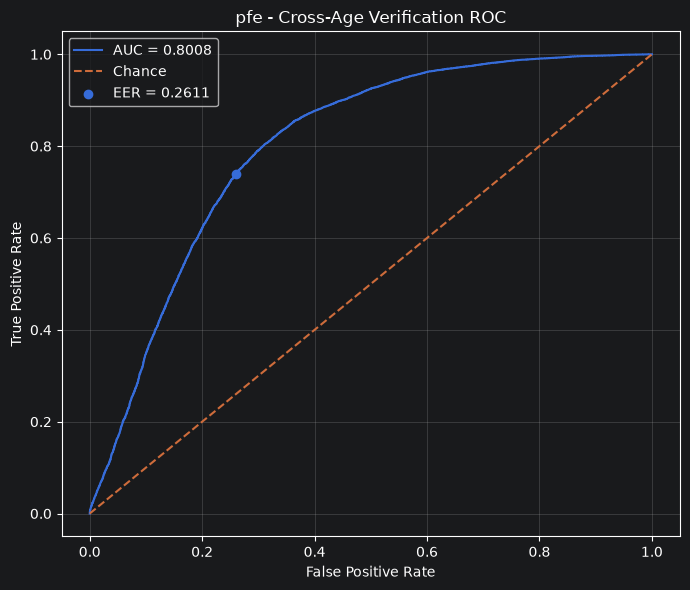

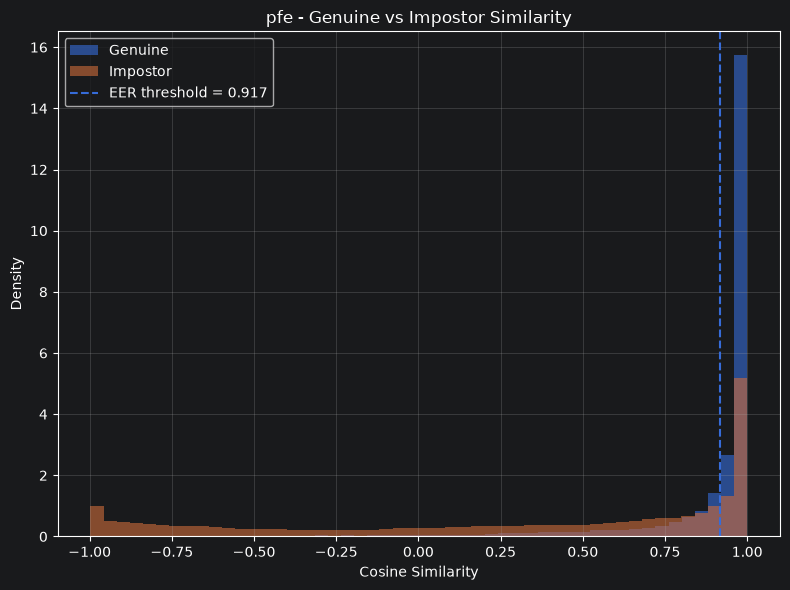

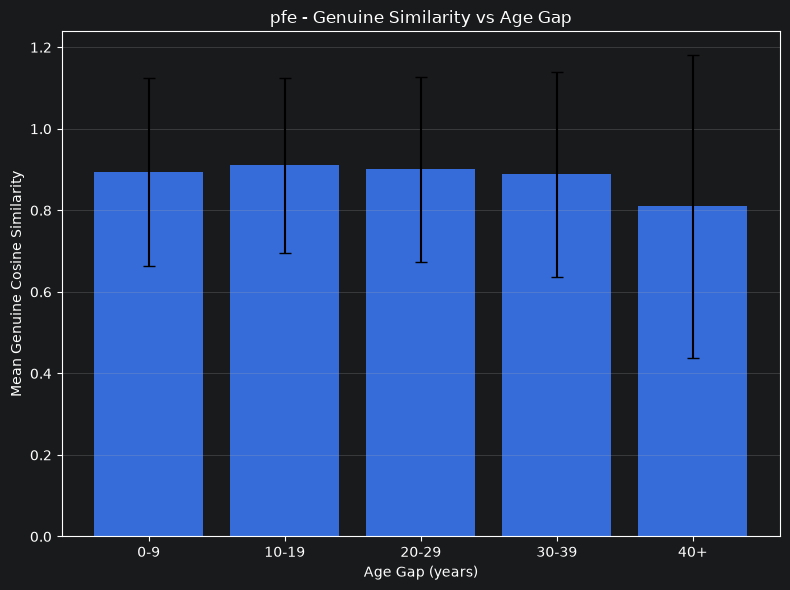

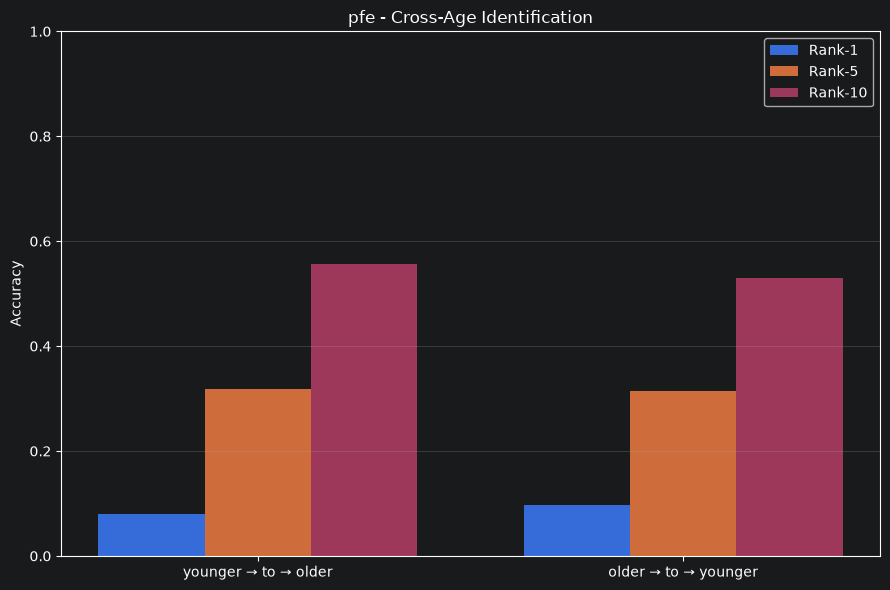

In [39]:
pipeline(pfe_config)

## 19. Experiment 3 — SphereFace

This run uses a deterministic embedding followed by a SphereFace-style angular classifier.

The configured margin is **4**, and the final training objective is implemented through cross-entropy on the classifier logits.

Remember the implementation detail documented above: the current training call omits labels when producing logits, so the angular margin is **not actually applied during the training forward pass**, while it is applied in validation. This matters when interpreting any comparison with the intended SphereFace formulation.


## SphereFace Run

In [38]:
preprocess_config = {
    "resize": True,
    "image_size": 224,
    "horizontal_flip": True,
    "rotation_degrees": 10,
    "color_jitter": True,
    "brightness": 0.15,
    "contrast": 0.15,
    "saturation": 0.15,
    "gaussian_noise": False,
    "gaussian_std": 0.05,
    "probability": 0.5,
    "salt_pepper_noise": False,
    "salt_pepper_probability": 0.01
}

loader_config = {
    "preprocess": preprocess_config,
    "person_balanced": True,
    "persons_per_batch": 16,
    "images_per_person": 4,
    "num_workers": 0,
    "pin_memory": True,
    "batch_size": 64
}

model_config = {
    "name": "sphereface",
    "backbone": "resnet50",
    "embedding_dim": 128,
    "pretrained": True,
    "num_classes": None,
    "margin": 4
}

sphereface_config = {
    "loader": loader_config,
    "model": model_config
}

1. Reading dataset manifest...
2. num_classes = 480 | max label = 479
3. Building loaders...
4. Loaders built.
5. Building model...
6. Model built.
7. Starting training...
Epoch 01/20 | Train Loss: 6.8251 | Validation Loss: 101.3380
Epoch 02/20 | Train Loss: 5.1889 | Validation Loss: 103.5691
Epoch 03/20 | Train Loss: 3.9275 | Validation Loss: 103.5500
Epoch 04/20 | Train Loss: 2.8589 | Validation Loss: 102.9571
Epoch 05/20 | Train Loss: 1.9206 | Validation Loss: 102.0775
Epoch 06/20 | Train Loss: 1.4104 | Validation Loss: 101.4376
Epoch 07/20 | Train Loss: 0.9632 | Validation Loss: 101.0762
Epoch 08/20 | Train Loss: 0.6467 | Validation Loss: 101.1842
Epoch 09/20 | Train Loss: 0.4693 | Validation Loss: 101.1147
Epoch 10/20 | Train Loss: 0.3398 | Validation Loss: 101.1563
Epoch 11/20 | Train Loss: 0.2548 | Validation Loss: 101.0841
Epoch 12/20 | Train Loss: 0.1948 | Validation Loss: 101.1869
Epoch 13/20 | Train Loss: 0.1463 | Validation Loss: 101.0198
Epoch 14/20 | Train Loss: 0.1194 | 

,age_gap_bin,count,mean,median,std,min,max
0,0-9,586,0.189390,0.182817,0.135453,-0.312184,0.674999
1,10-19,3448,0.186726,0.180736,0.131163,-0.215591,0.930097
2,20-29,4543,0.164640,0.156238,0.128693,-0.215339,0.693629
3,30-39,3668,0.144837,0.136594,0.131631,-0.262855,0.606928
4,40+,3525,0.119929,0.117886,0.115497,-0.253559,0.578150


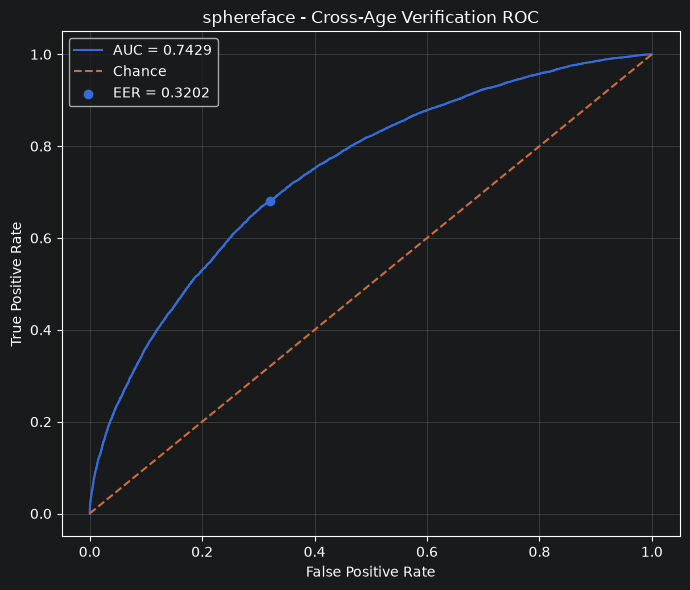

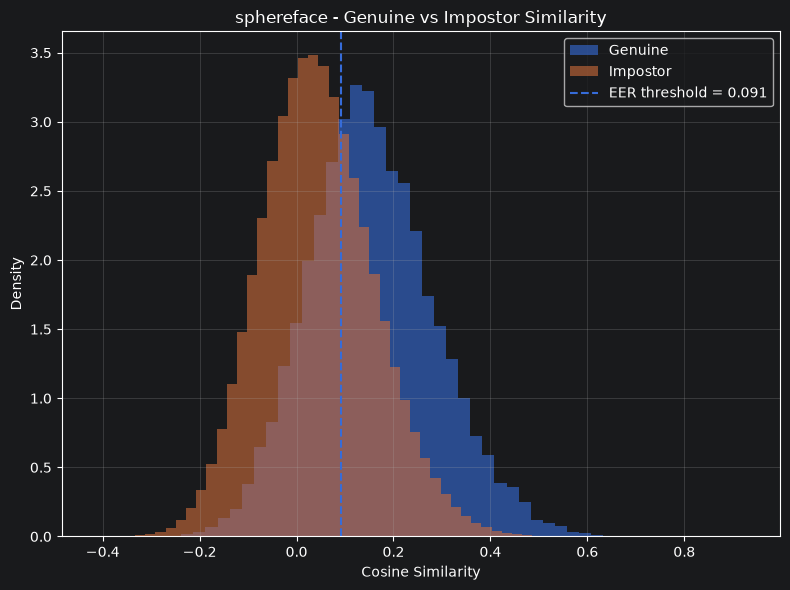

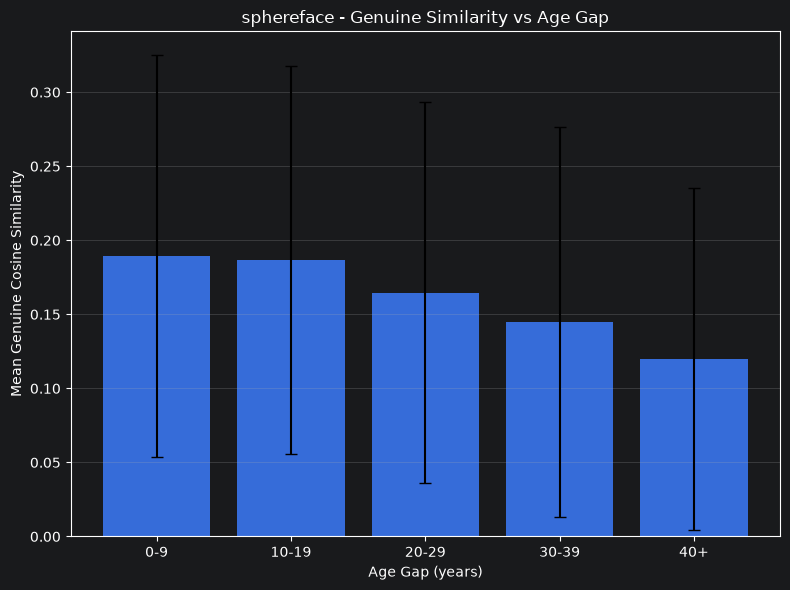

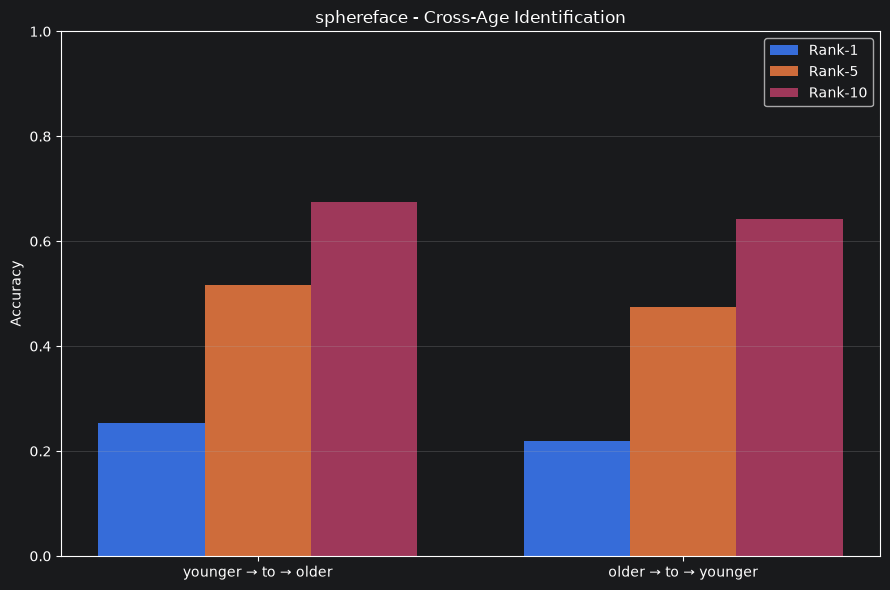

In [39]:
pipeline(sphereface_config)

## 20. Experiment 4 — AdaFace

This run uses an adaptive angular-margin classifier with:

- base margin = **0.4**
- $h=0.333$
- scale = **64**
- exponential-moving-average update parameter $t_\alpha=0.01$

The classifier adapts the target margin using the norm of the embedding as a quality signal.

The main question is:

> Does quality-aware angular supervision produce embeddings that are more robust to the difficult cross-age setting?


## AdaFace Run

In [40]:
preprocess_config = {
    "resize": True,
    "image_size": 224,
    "horizontal_flip": True,
    "rotation_degrees": 10,
    "color_jitter": True,
    "brightness": 0.15,
    "contrast": 0.15,
    "saturation": 0.15,
    "gaussian_noise": False,
    "gaussian_std": 0.05,
    "probability": 0.5,
    "salt_pepper_noise": False,
    "salt_pepper_probability": 0.01
}

loader_config = {
    "preprocess": preprocess_config,
    "person_balanced": True,
    "persons_per_batch": 16,
    "images_per_person": 4,
    "num_workers": 0,
    "pin_memory": True,
    "batch_size": 64
}

model_config = {
    "name": "adaface",
    "backbone": "resnet50",
    "embedding_dim": 128,
    "pretrained": True,
    "num_classes": None,
    "margin": 0.4,
    "h": 0.333,
    "scale": 64.0,
    "t_alpha": 0.01
}

adaface_config = {
    "loader": loader_config,
    "model": model_config
}

1. Reading dataset manifest...
2. num_classes = 480 | max label = 479
3. Building loaders...
4. Loaders built.
5. Building model...
6. Model built.
7. Starting training...
Epoch 01/20 | Train Loss: 37.6751 | Train Acc: 0.0343 | Val Loss: 16.0667 | Val Acc: 0.0000
Epoch 02/20 | Train Loss: 29.2115 | Train Acc: 0.0940 | Val Loss: 16.9902 | Val Acc: 0.0000
Epoch 03/20 | Train Loss: 23.4884 | Train Acc: 0.1932 | Val Loss: 18.4564 | Val Acc: 0.0000
Epoch 04/20 | Train Loss: 21.1829 | Train Acc: 0.3314 | Val Loss: 21.7739 | Val Acc: 0.0000
Epoch 05/20 | Train Loss: 21.2324 | Train Acc: 0.4358 | Val Loss: 21.3138 | Val Acc: 0.0000
Epoch 06/20 | Train Loss: 20.8844 | Train Acc: 0.5286 | Val Loss: 19.8270 | Val Acc: 0.0000
Epoch 07/20 | Train Loss: 19.8207 | Train Acc: 0.5980 | Val Loss: 19.4496 | Val Acc: 0.0000
Epoch 08/20 | Train Loss: 18.9546 | Train Acc: 0.6561 | Val Loss: 19.1755 | Val Acc: 0.0000
Epoch 09/20 | Train Loss: 17.7399 | Train Acc: 0.6959 | Val Loss: 19.7054 | Val Acc: 0.0000


,age_gap_bin,count,mean,median,std,min,max
0,0-9,586,0.166290,0.163945,0.127561,-0.251775,0.544831
1,10-19,3448,0.159624,0.155023,0.119396,-0.214814,0.940418
2,20-29,4543,0.139930,0.138124,0.115512,-0.222963,0.727761
3,30-39,3668,0.123045,0.120106,0.115143,-0.244054,0.637180
4,40+,3525,0.099151,0.097179,0.110584,-0.287058,0.447883


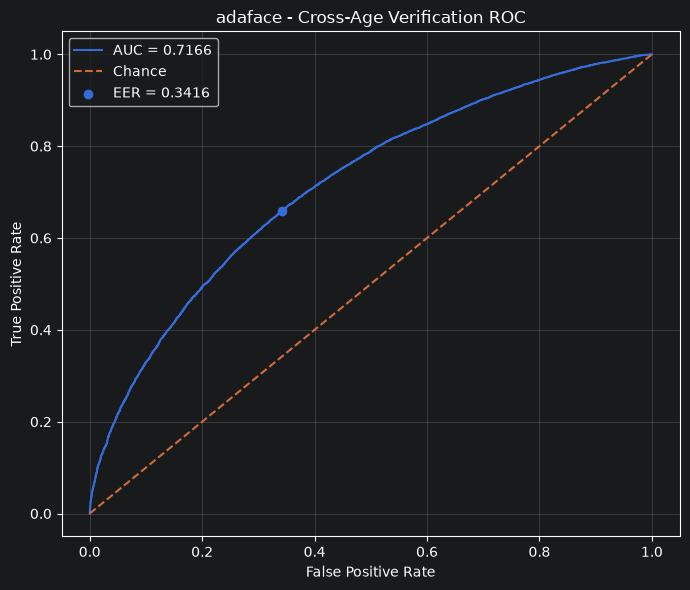

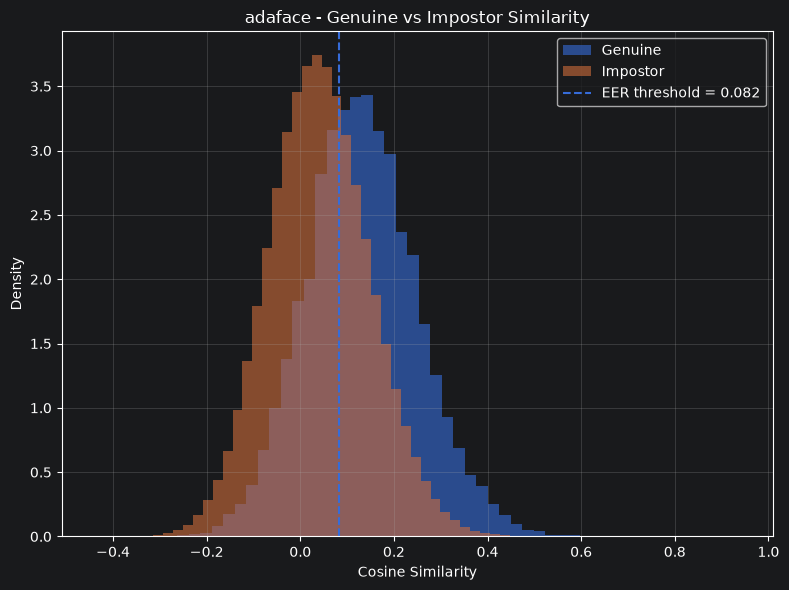

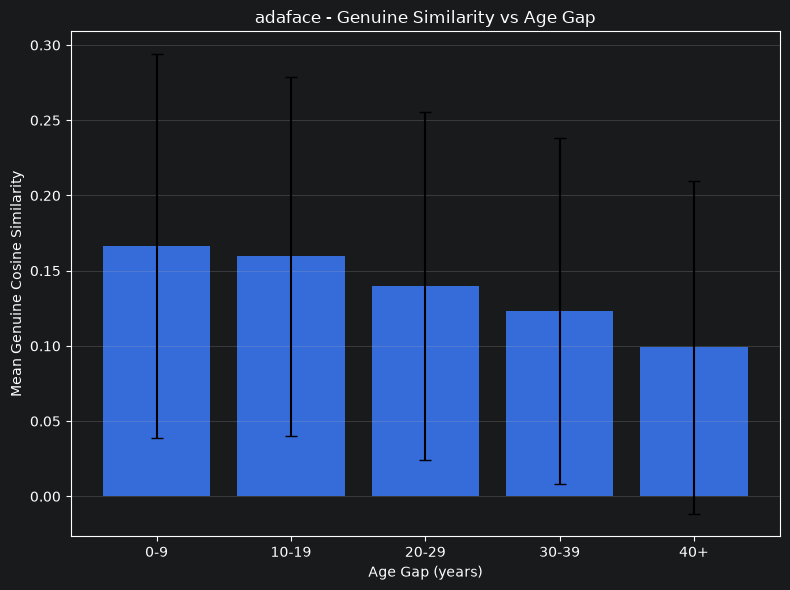

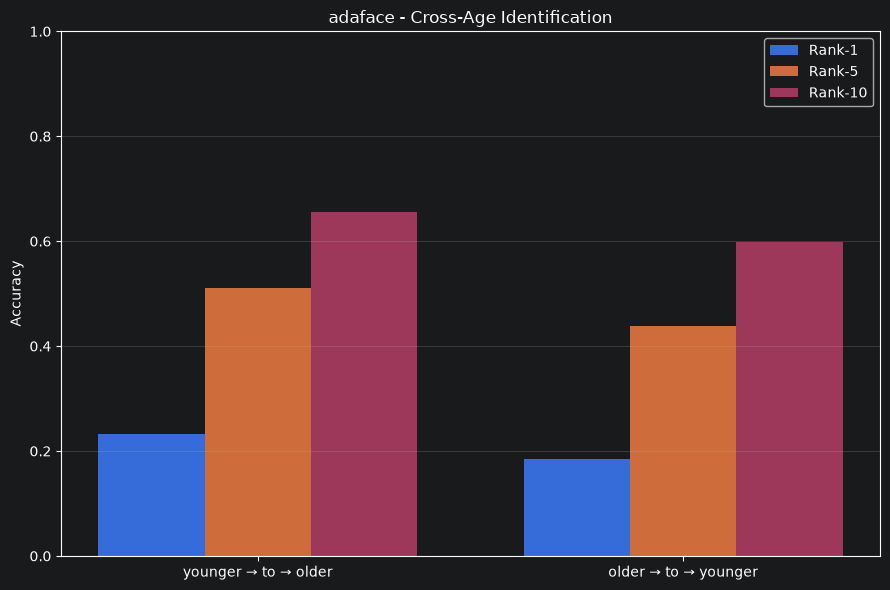

In [41]:
pipeline(adaface_config)